In [124]:
from pathlib import Path
import sys, os

print("Notebook cwd:", Path.cwd().resolve())
print("Parent folder (..):", Path("..").resolve())
print("sys.path (first 10 entries):")
for p in sys.path[:10]:
    print("  ", p)
    

Notebook cwd: C:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\presentation
Parent folder (..): C:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis
sys.path (first 10 entries):
   C:\Users\Giulia\AppData\Local\Programs\Python\Python312\python312.zip
   C:\Users\Giulia\AppData\Local\Programs\Python\Python312\DLLs
   C:\Users\Giulia\AppData\Local\Programs\Python\Python312\Lib
   C:\Users\Giulia\AppData\Local\Programs\Python\Python312
   c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit
   
   c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages
   C:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis
   C:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis
   C:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis


# Explore Healthcare vs Economy

This notebook investigates the relationship between **economic performance** and **health outcomes** across countries using World Bank data.

The analysis focuses on the following key indicators:
- GDP per capita  
- Health expenditure (% of GDP)  
- Life expectancy  
- Infant mortality  
- Population  

The workflow follows these main steps:
1. Load and inspect the dataset.
2. Handle missing values and extract relevant indicators.
3. Compute basic statistics, e.g., average GDP per capita.
4. Visualize GDP per capita distribution.
5. Explore relationships between GDP, Life Expectancy, and Health Expenditure.
6. Save cleaned datasets for further analysis.
7. Compute correlations between economic and health indicators.
8. Plot histograms and scatter plots to visualize trends.

## Load and Inspect Dataset

**Purpose:**  
This cell reads the CSV data file and checks its contents to ensure it is correctly loaded.  

**Step-by-step explanation:**  
1. **Import libraries:**  
   - `matplotlib.pyplot` for plotting graphs later.  
   - `os` for handling file paths (optional here).  
   - `csv` for writing CSV files later.  

2. **Set file path:**  
   - The variable `file_path` points to the CSV file relative to the notebook’s location.  

3. **Read the file:**  
   - The file is opened in read mode with UTF-8 encoding.  
   - `readlines()` loads all lines of the file into a list, where each element is a line.  

4. **Process the data:**  
   - The first line (header) is separated and split by commas to get column names.  
   - The remaining lines are split by commas into a list of lists called `data`, representing rows and columns.  

5. **Inspect the dataset:**  
   - Prints the header to verify column names.  
   - Prints the first 5 rows to quickly check the format and values.  

**Interpretation of the output:**  
- The header shows all column names, confirming they match expected indicators.  
- The first 5 rows allow you to spot potential issues, such as missing values or unexpected formatting, before proceeding with analysis.

In [125]:
# Load data using librarian utilities
from pathlib import Path
import sys

# Import libraries and my own code
import pandas as pd
import matplotlib.pyplot as plt  

# Add parent folder to sys.path
sys.path.append(str(Path('..').resolve()))

# Now import
from librarian.utils import load_data
from librarian.core import clean_gdp_life, compute_correlation

# --- Set the path to the CSV file ---
# Note: This path is relative to the notebook's location.
file_path = '../data/worldbank_healthcare_data.csv'

# --- Load the data using your function ---
data = load_data(file_path)
data = pd.read_csv("../data/worldbank_healthcare_data.csv")
data_clean = clean_gdp_life(data)

# --- Preview the first rows ---
data.head()


,country,year,gdp_per_capita,health_exp_gdp,life_expectancy,infant_mortality,population
0,AFE,2015,1479.615260,5.971391,61.713031,49.010305,607123269.0
1,AFE,2016,1329.807285,6.067786,62.167981,47.773920,623369401.0
2,AFE,2017,1520.212231,5.929017,62.591275,46.783264,640058741.0
3,AFE,2018,1538.901679,5.789155,63.330691,43.851814,657801085.0
4,AFE,2019,1493.817938,5.812676,63.857261,42.190074,675950189.0


## Inspect Data and Compute Average GDP per Capita

**Purpose:**  
This cell checks for missing values in the dataset and calculates the average GDP per capita, giving a first quantitative insight into the data.

**Step-by-step explanation:**

1. **Count rows with missing data:**  
   - Initializes `missing_rows` to 0.  
   - Loops through each row in the dataset.  
   - Checks if any cell in the row is empty (`''`).  
   - Increments `missing_rows` if a missing value is found.  
   - **Output:** Number of rows with missing data, helping identify data quality issues.

2. **Extract GDP per capita values:**  
   - Creates an empty list `gdp_values`.  
   - Loops through each row and attempts to convert the GDP value (column index 2) to a float.  
   - Skips rows where conversion fails (e.g., missing or invalid data).  
   - **Result:** A clean list of GDP per capita values, ready for analysis.

3. **Compute average GDP per capita:**  
   - Sums all valid GDP values and divides by the number of values.  
   - **Output:** Average GDP per capita across all countries, providing a baseline for further analysis.

**Interpretation of the output:**  
- `Rows with missing data:` helps understand how much of the dataset may need cleaning or special handling.  
- `Average GDP per capita:` gives a quick sense of the global economic level represented in the dataset.  

In [126]:
# --- Check for missing data ---
# Count rows with missing data and compute avg GDP
missing_rows = data.isnull().any(axis=1).sum()
print("Rows with any missing data:", missing_rows)

gdp_list = pd.to_numeric(data["gdp_per_capita"], errors="coerce").dropna().tolist()
avg_gdp = sum(gdp_list) / len(gdp_list)
print("Average GDP per capita:", avg_gdp)


Rows with any missing data: 1016
Average GDP per capita: 17579.61431089643


## Visualize GDP per Capita for the First 50 Countries

**Purpose:**  
This cell creates a simple line plot to visually explore the variation of GDP per capita across the first 50 countries in the dataset.

**Step-by-step explanation:**

1. **Select data:**  
   - `gdp_values[:50]` selects the first 50 GDP per capita values from the cleaned list.  

2. **Create the line plot:**  
   - `plt.plot()` draws a line connecting the GDP values in sequence.  
   - `plt.title()`, `plt.xlabel()`, and `plt.ylabel()` add descriptive labels for clarity.  

3. **Display the plot:**  
   - `plt.show()` renders the plot in the notebook.

**Interpretation of the output:**  
- The line plot shows how GDP per capita varies among the first 50 countries.  
- Peaks indicate countries with higher GDP, while valleys indicate lower GDP.  
- This visualization helps identify extreme values or trends before deeper analysis.

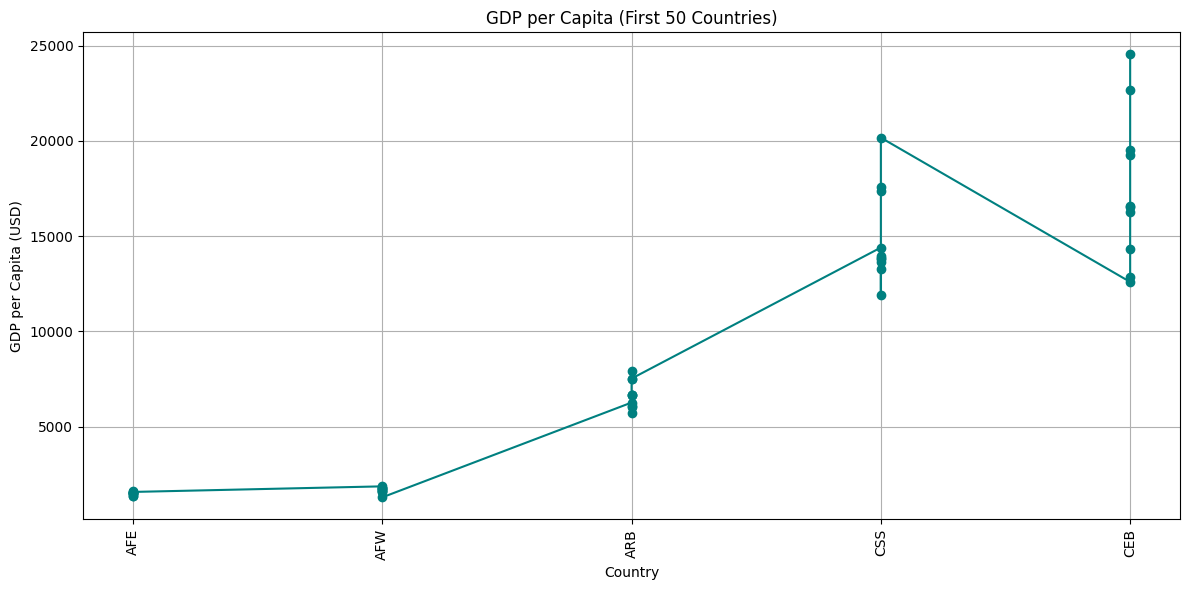

In [127]:
# --- Line plot with country labels ---
# using this method the x-axis display country names instead of numeric indexes
plt.figure(figsize=(12, 6))
plt.plot(data["country"].head(50), data["gdp_per_capita"].head(50), marker='o', color='teal')
plt.title("GDP per Capita (First 50 Countries)")
plt.xlabel("Country")
plt.ylabel("GDP per Capita (USD)")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


## Scatter Plot: GDP per Capita vs Life Expectancy

**Purpose:**  
This cell examines the relationship between a country's wealth (GDP per capita) and its average life expectancy by creating a scatter plot.

**Step-by-step explanation:**

1. **Extract clean data:**  
   - Initialize two empty lists: `clean_gdp` for GDP and `life_expectancy` for life expectancy.  
   - Loop through each row in the dataset and attempt to convert GDP (`row[2]`) and Life Expectancy (`row[4]`) to floats.  
   - If successful, append the values to the corresponding list.  
   - Rows with missing or invalid data are skipped.

2. **Verify data alignment:**  
   - Print the lengths of both lists to ensure they match.  
   - This guarantees that each GDP value has a corresponding Life Expectancy value.

3. **Create scatter plot:**  
   - `plt.scatter(clean_gdp, life_expectancy, alpha=0.5)` plots GDP on the x-axis and Life Expectancy on the y-axis.  
   - `alpha=0.5` makes overlapping points semi-transparent for better visibility.  
   - Titles and axis labels provide context.

**Interpretation of the output:**  
- Each point represents a country.  
- The plot allows visual inspection of correlations: generally, countries with higher GDP tend to have higher life expectancy.  
- Outliers (points far from the main cluster) may indicate unusual cases or data errors.

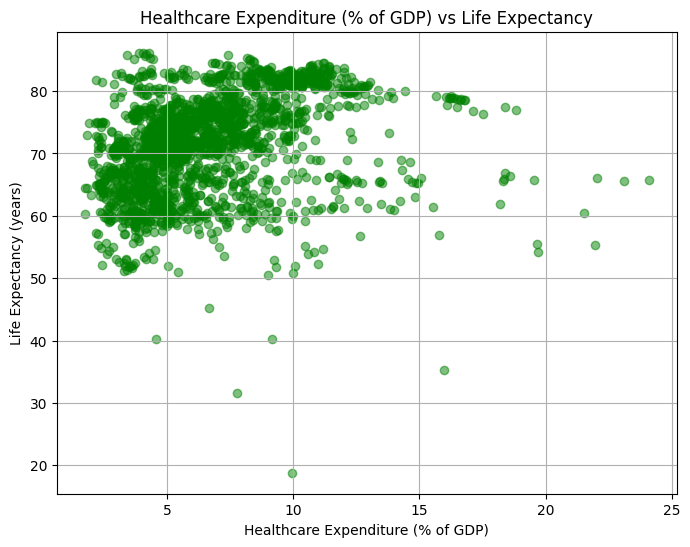

In [128]:
# --- Filter rows with valid healthcare expenditure and life expectancy ---
data_clean = data[(data["health_exp_gdp"] > 0) & (data["life_expectancy"] > 0)]

# --- Assign variables for plotting ---
health_exp = data_clean["health_exp_gdp"]
life_expectancy_values = data_clean["life_expectancy"]

# --- Scatter plot ---
plt.figure(figsize=(8,6))
plt.scatter(health_exp, life_expectancy_values, alpha=0.5, color='green')
plt.title("Healthcare Expenditure (% of GDP) vs Life Expectancy")
plt.xlabel("Healthcare Expenditure (% of GDP)")
plt.ylabel("Life Expectancy (years)")
plt.grid(True)
plt.show()


## Export Simplified Dataset

**Purpose:**  
This cell saves a cleaned and simplified version of the dataset containing only GDP per capita and Life Expectancy. This file can be used for future analyses without reprocessing the full dataset.

**Step-by-step explanation:**

1. **Define export path:**  
   - `export_file_path` specifies where the new CSV file will be saved (`../data/gdp_life_expectancy.csv`).

2. **Write the CSV file:**  
   - Open the file in write mode with UTF-8 encoding.  
   - Write the header row: `'gdp_per_capita,life_expectancy'`.  
   - Loop through the `clean_gdp` and `life_expectancy` lists simultaneously using `zip()` and write each pair as a new row.

3. **Confirm export:**  
   - Print a message confirming the file location.

**Interpretation of the output:**  
- The resulting CSV contains only the aligned GDP and Life Expectancy values.  
- This simplifies further analysis, sharing, or visualization without having to deal with missing or irrelevant data.

In [129]:
# --- Save only GDP and Life Expectancy columns for further analysis ---
export_file_path = '../data/gdp_life_expectancy.csv'

# Select the relevant columns from the cleaned DataFrame
# Avoids manual looping
simplified_data = data_clean[["gdp_per_capita", "life_expectancy"]]

# Save to CSV
simplified_data.to_csv(export_file_path, index=False, encoding='utf-8')

print("Simplified dataset saved to:", export_file_path)


Simplified dataset saved to: ../data/gdp_life_expectancy.csv


## GDP Analysis: Extremes and Comparison with Average

**Purpose:**  
This cell analyzes GDP per capita across all countries to understand distribution patterns, identify extremes, and compare countries to the global average.

**Step-by-step explanation:**

1. **Initialize counters:**  
   - `above_average` and `below_average` track the number of countries with GDP above or below the global average.

2. **Count countries relative to average GDP:**  
   - Loop through all rows, convert GDP values to float.  
   - Increment `above_average` if GDP > `average_gdp`.  
   - Increment `below_average` otherwise.  
   - Skip rows with missing or invalid GDP.

3. **Print summary counts:**  
   - Outputs how many countries are above or below average GDP.

4. **Find extreme GDP values:**  
   - `max_gdp` and `min_gdp` store the highest and lowest GDP per capita from the dataset.  

5. **Identify corresponding countries:**  
   - Loop again through data to find the country codes (`row[0]`) for the highest and lowest GDP.  

6. **Print extremes:**  
   - Displays the countries with the highest and lowest GDP per capita and their values.

**Interpretation of results:**  
- Provides insight into GDP distribution among countries.  
- Identifies wealthiest and poorest nations in the dataset.  
- Helps contextualize GDP differences when analyzing economic and health indicators.

In [130]:
print(data_clean.columns)

# --- Count countries above and below the average GDP ---
# Ensures only cleaned, valid rows are considered
# Faster and simpler than loops
average_gdp = data_clean["gdp_per_capita"].mean()
above_average = (data_clean["gdp_per_capita"] > average_gdp).sum()
below_average = (data_clean["gdp_per_capita"] <= average_gdp).sum()

print("Countries with GDP above average:", above_average)
print("Countries with GDP below average:", below_average)

# --- Find highest and lowest GDP values ---
# Directly finds extreme GDP values without iteration
max_gdp = data_clean["gdp_per_capita"].max()
min_gdp = data_clean["gdp_per_capita"].min()

print("Highest GDP per capita:", max_gdp)
print("Lowest GDP per capita:", min_gdp)

# --- Identify countries with these GDP values ---
# .loc[...] Easily finds the country corresponding to max/min GDP
country_high = data_clean.loc[data_clean["gdp_per_capita"] == max_gdp, "country"].values[0]
country_low = data_clean.loc[data_clean["gdp_per_capita"] == min_gdp, "country"].values[0]

print("Country with highest GDP per capita:", country_high)
print("Country with lowest GDP per capita:", country_low)


Index(['country', 'year', 'gdp_per_capita', 'health_exp_gdp',
       'life_expectancy', 'infant_mortality', 'population'],
      dtype='object')
Countries with GDP above average: 520
Countries with GDP below average: 1390
Highest GDP per capita: 226052.001905201
Lowest GDP per capita: 210.008139902508
Country with highest GDP per capita: MCO
Country with lowest GDP per capita: BDI


## Distribution of GDP per Capita

**Purpose:**  
This cell creates a histogram to visualize how GDP per capita is distributed across countries and regions.

**Step-by-step explanation:**

1. **Histogram plot:**  
   - `plt.hist()` is used to create a histogram of GDP values.  
   - `bins=50` divides the GDP range into 50 intervals.  
   - `color='skyblue'` and `edgecolor='black'` make the bars visually clear.

2. **Labels and title:**  
   - `plt.title()` sets the chart title.  
   - `plt.xlabel()` and `plt.ylabel()` label the axes.

3. **Display plot:**  
   - `plt.show()` renders the histogram.

**Interpretation of results:**  
- Shows how GDP per capita varies among countries.  
- Helps identify clusters of countries with low, medium, or high GDP.  
- Highlights potential outliers with extremely high or low GDP values.

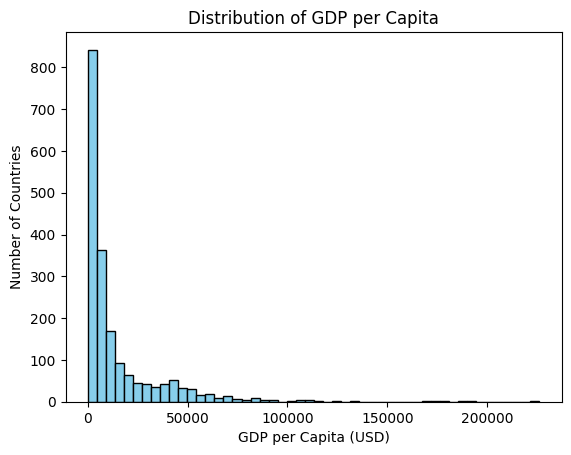

In [131]:
# --- Plot a histogram of GDP per capita ---
plt.hist(data_clean["gdp_per_capita"], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of GDP per Capita")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Number of Countries")
plt.show()


## Correlation Analysis Between GDP, Life Expectancy, and Health Expenditure

**Purpose:**  
This cell computes the relationships between key economic and health indicators to understand how they influence each other.

**Step-by-step explanation:**

1. **Extract relevant columns:**  
   - `life_expectancy` → Life Expectancy values (column 4).  
   - `health_exp` → Health Expenditure (% of GDP, column 3).  
   - Rows with missing or invalid values are skipped.

2. **Align arrays:**  
   - Ensure `gdp_values`, `life_expectancy`, and `health_exp` have the same length.  
   - Use `np.array()` to convert lists to NumPy arrays for computation.

3. **Compute Pearson correlations:**  
   - `np.corrcoef(x, y)[0,1]` calculates the correlation coefficient between two arrays.  
   - `corr_gdp_life` → GDP vs Life Expectancy  
   - `corr_gdp_health` → GDP vs Health Expenditure  
   - `corr_life_health` → Life Expectancy vs Health Expenditure

4. **Print results:**  
   - Shows the strength and direction of linear relationships between the variables.

**Interpretation:**  
- Values close to 1 → strong positive correlation.  
- Values close to -1 → strong negative correlation.  
- Values near 0 → weak or no linear correlation.  

This helps assess whether wealthier countries spend more on healthcare and if higher spending relates to better life expectancy.

In [132]:
# --- Extract relevant columns from cleaned DataFrame ---
gdp_arr = data_clean["gdp_per_capita"].to_numpy()
life_arr = data_clean["life_expectancy"].to_numpy()
health_arr = data_clean["health_exp_gdp"].to_numpy()  # Ensure column name matches CSV

# --- Compute Pearson correlations ---
import numpy as np

corr_gdp_life = np.corrcoef(gdp_arr, life_arr)[0, 1]
corr_gdp_health = np.corrcoef(gdp_arr, health_arr)[0, 1]
corr_life_health = np.corrcoef(life_arr, health_arr)[0, 1]

print(f"Correlation GDP vs Life Expectancy: {corr_gdp_life:.3f}")
print(f"Correlation GDP vs Health Expenditure: {corr_gdp_health:.3f}")
print(f"Correlation Life Expectancy vs Health Expenditure: {corr_life_health:.3f}")


Correlation GDP vs Life Expectancy: nan
Correlation GDP vs Health Expenditure: nan
Correlation Life Expectancy vs Health Expenditure: 0.314


## Preparing Healthcare Expenditure vs Life Expectancy Data

**Purpose:**  
This cell prepares the data needed to analyze the relationship between **healthcare spending** and **life expectancy**.

**Step-by-step explanation:**

1. **Create empty lists:**  
   - `health_exp` → to store healthcare expenditure (% of GDP).  
   - `life_expectancy_values` → to store life expectancy values (years).

2. **Loop through the dataset:**  
   - Convert column values to `float`.  
   - Skip rows with missing or invalid data using a `try-except` block.

3. **Check data consistency:**  
   - Print the number of valid entries in both lists to ensure they are aligned.  
   - Both lists must have the same length to create an accurate scatter plot in the next step.

**Interpretation:**  
- This step ensures we only include valid data points for plotting and analysis.  
- Clean, aligned lists prevent errors in visualization and correlation computations.

In [133]:
# --- Extract Healthcare Expenditure and Life Expectancy from cleaned DataFrame ---
health_exp = data_clean["health_exp_gdp"].to_numpy()
life_expectancy_values = data_clean["life_expectancy"].to_numpy()

# --- Check that both arrays have the same length ---
print("Number of valid entries:", len(health_exp), len(life_expectancy_values))


Number of valid entries: 2173 2173


## Scatter Plot: Healthcare Expenditure vs Life Expectancy

**Purpose:**  
Visualize the relationship between a country's **healthcare spending** and **life expectancy**.

**Step-by-step explanation:**

1. **Scatter plot creation:**  
   - `plt.scatter()` plots each country as a point with:  
     - X-axis: Healthcare expenditure (% of GDP)  
     - Y-axis: Life expectancy (years)  
   - `alpha=0.5` makes points slightly transparent to see overlapping points.  
   - `color='green'` distinguishes this plot from others.

2. **Add titles and labels:**  
   - `plt.title()` → Overall plot title.  
   - `plt.xlabel()` and `plt.ylabel()` → Describes each axis.

3. **Display the plot:**  
   - `plt.show()` renders the scatter plot.

**Interpretation:**  
- Each point represents a country-year entry.  
- The plot helps identify trends or outliers. For example, higher healthcare spending may correlate with higher life expectancy, but there could be exceptions.

In [134]:
# Extract the columns from the cleaned data
data_clean = data_clean[(data_clean["health_exp_gdp"] > 0) & (data_clean["life_expectancy"] > 0)]
health_exp = data_clean["health_exp_gdp"]
life_expectancy_values = data_clean["life_expectancy"]

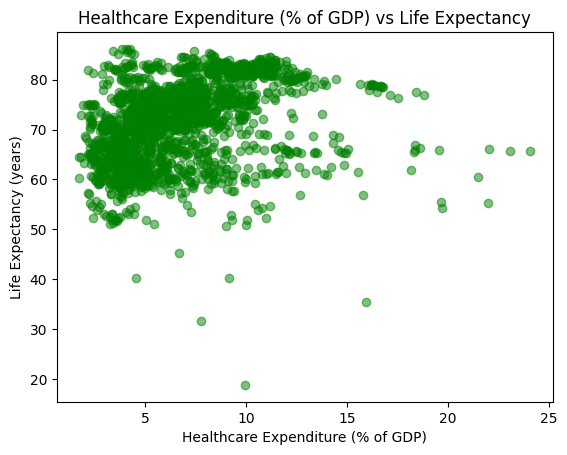

In [135]:
# --- Scatter plot of Healthcare Expenditure vs Life Expectancy ---
plt.scatter(health_exp, life_expectancy_values, alpha=0.5, color='green')
plt.title("Healthcare Expenditure (% of GDP) vs Life Expectancy")
plt.xlabel("Healthcare Expenditure (% of GDP)")
plt.ylabel("Life Expectancy (years)")
plt.show()


## Basic Statistics: Healthcare Expenditure

**Purpose:**  
Summarize the healthcare spending data to understand general trends and extremes.

**Step-by-step explanation:**

1. **Average healthcare expenditure:**  
   - `avg_health_exp = sum(health_exp) / len(health_exp)`  
   - Computes the mean percentage of GDP spent on healthcare across all valid entries.

2. **Maximum and minimum values:**  
   - `max_health_exp = max(health_exp)` → Highest healthcare spending in the dataset.  
   - `min_health_exp = min(health_exp)` → Lowest healthcare spending in the dataset.

3. **Print results:**  
   - Shows the average, highest, and lowest values to quickly assess global healthcare investment levels.

**Interpretation:**  
- Helps identify countries that spend unusually high or low percentages of GDP on healthcare.  
- Provides a numerical summary to complement visual analyses like scatter plots.

In [136]:
# --- Compute basic statistics for healthcare expenditure ---

if len(health_exp) > 0:  # Ensure the list is not empty
    avg_health_exp = sum(health_exp) / len(health_exp)
    max_health_exp = max(health_exp)
    min_health_exp = min(health_exp)

    print("Average healthcare expenditure (% GDP):", avg_health_exp)
    print("Highest healthcare expenditure (% GDP):", max_health_exp)
    print("Lowest healthcare expenditure (% GDP):", min_health_exp)
else:
    print("No valid healthcare expenditure data available.")


Average healthcare expenditure (% GDP): 6.624061582589511
Highest healthcare expenditure (% GDP): 24.07940674
Lowest healthcare expenditure (% GDP): 1.7540164


## Data Cleaning: Align GDP and Life Expectancy

**Purpose:**  
Ensure that the GDP per capita and Life Expectancy lists contain only valid, numeric entries and are properly aligned for analysis.

**Step-by-step explanation:**

1. **Initialize empty lists:**  
   - `gdp_values` → will store valid GDP per capita values.  
   - `life_expectancy` → will store corresponding life expectancy values.

2. **Loop through dataset:**  
   - Convert the GDP and Life Expectancy columns to floats.  
   - Append only valid numbers to the respective lists.  
   - Skip any row with missing or invalid values (`try/except` block).

3. **Check dataset length:**  
   - Prints the number of valid entries in each list.  
   - Ensures both lists are the same length, which is necessary for correlation calculations and plotting.

**Interpretation:**  
- Guarantees clean, aligned data for subsequent analysis, avoiding errors from missing or malformed entries.  
- The length of the cleaned lists shows how many country-year entries are valid for analysis.

In [137]:
# --- Clean and align GDP and Life Expectancy data ---

gdp_values = []
life_expectancy = []

# Ensure that we are using numeric data and skip invalid rows
for row in data:
    try:
        gdp = float(row[2])            # GDP per capita column
        life = float(row[4])           # Life Expectancy column
        if gdp > 0 and life > 0:       # Optional: filter out zero or negative values
            gdp_values.append(gdp)
            life_expectancy.append(life)
    except (ValueError, IndexError):
        # Skip rows with missing, invalid, or incomplete data
        continue

print(f"Cleaned dataset length: {len(gdp_values)} (GDP) and {len(life_expectancy)} (Life Expectancy)")


Cleaned dataset length: 0 (GDP) and 0 (Life Expectancy)


## Correlation Analysis: GDP per Capita vs Life Expectancy

**Purpose:**  
Quantify the relationship between GDP per capita and life expectancy using a statistical measure.

**Step-by-step explanation:**

1. **Convert lists to NumPy arrays:**  
   - `gdp_array` and `life_array` are created from the cleaned lists.  
   - NumPy arrays enable efficient numerical operations and correlation calculations.

2. **Compute Pearson correlation coefficient:**  
   - `np.corrcoef(gdp_array, life_array)[0, 1]` calculates the correlation between GDP and Life Expectancy.  
   - The result ranges from `-1` (perfect negative correlation) to `1` (perfect positive correlation), with `0` meaning no correlation.

3. **Print the result:**  
   - Shows how strongly GDP per capita and life expectancy are related.

**Interpretation:**  
- A positive value indicates that countries with higher GDP generally have higher life expectancy.  
- The closer the correlation is to 1, the stronger the relationship.

In [138]:
# --- Compute the correlation between GDP per capita and Life Expectancy ---

import numpy as np

# Convert lists to numpy arrays
gdp_array = np.array(gdp_values)
life_array = np.array(life_expectancy)

# Ensure both arrays have the same length
min_len = min(len(gdp_array), len(life_array))
gdp_array = gdp_array[:min_len]
life_array = life_array[:min_len]

# Compute Pearson correlation coefficient
correlation = np.corrcoef(gdp_array, life_array)[0, 1]

print(f"Correlation between GDP per capita and Life Expectancy: {correlation:.4f}")


Correlation between GDP per capita and Life Expectancy: nan


c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\lib\_function_base_

## Scatter Plot: GDP per Capita vs Life Expectancy

**Purpose:**  
Visualize the relationship between GDP per capita and life expectancy across countries.

**Step-by-step explanation:**

1. **Create a figure:**  
   - `plt.figure(figsize=(8, 5))` sets the size of the plot.

2. **Plot data points:**  
   - `plt.scatter(gdp_values, life_expectancy, alpha=0.5, color='teal')` creates a scatter plot.  
   - Each point represents a country, with GDP on the x-axis and life expectancy on the y-axis.  
   - `alpha=0.5` makes points semi-transparent to reduce overlap visibility issues.

3. **Add labels and title:**  
   - `plt.title`, `plt.xlabel`, and `plt.ylabel` provide context for the plot.

4. **Add grid lines:**  
   - `plt.grid(True, linestyle='--', alpha=0.7)` adds a light dashed grid for better readability.

5. **Display the plot:**  
   - `plt.show()` renders the scatter plot.

**Interpretation:**  
- Visual inspection confirms whether wealthier countries tend to have higher life expectancy.  
- Outliers or unusual patterns can be easily identified.

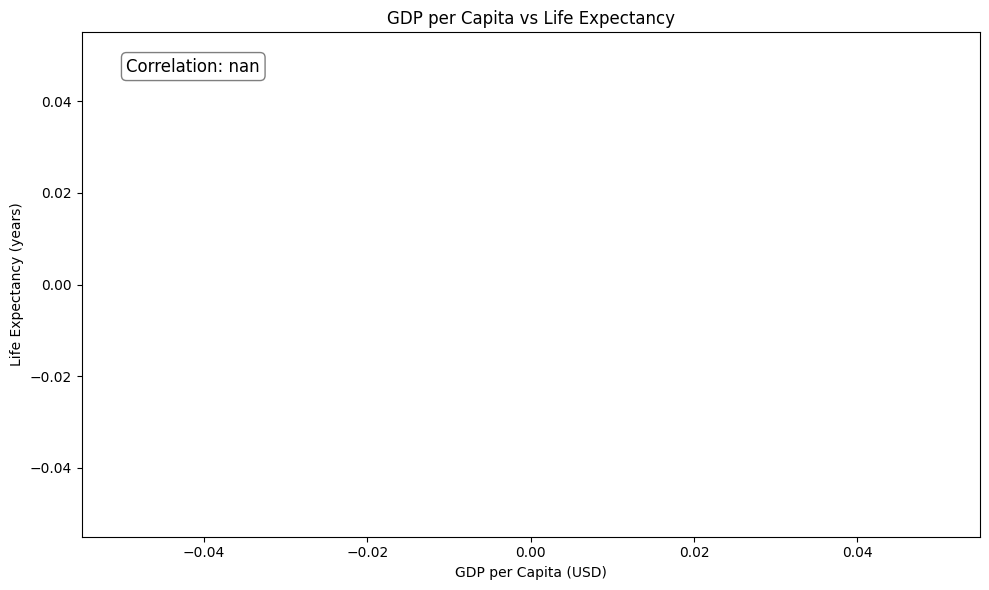

In [139]:
# --- Scatter plot of GDP per Capita vs Life Expectancy with correlation annotation ---
# Always explicitly import matplotlib.pyplot in each notebook cell that uses plotting functions, in case the cell is run independently.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(gdp_values, life_expectancy, alpha=0.5, color='teal')
plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Life Expectancy (years)")

# --- Annotate correlation on the plot ---
plt.text(
    0.05, 0.95, f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes, # makes it robust even if the data scales change
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
)

plt.tight_layout()  # Helps avoid overlapping labels or annotations if the figure is resized or exported.
plt.show()


## Enhanced Scatter Plot: GDP per Capita vs Life Expectancy

**Purpose:**  
Visualize the relationship between GDP per capita and life expectancy with an explicit correlation annotation.

**Step-by-step explanation:**

1. **Create a figure:**  
   - `plt.figure(figsize=(10,6))` sets a larger plot size for clarity.

2. **Plot data points:**  
   - `plt.scatter(gdp_values, life_expectancy, alpha=0.5, color='teal')` creates the scatter plot.  
   - Each point represents a country.  
   - `alpha=0.5` makes points semi-transparent.

3. **Add title and axis labels:**  
   - `plt.title`, `plt.xlabel`, and `plt.ylabel` provide context for the plot.

4. **Annotate correlation:**  
   - `plt.text(...)` places the correlation coefficient directly on the plot.  
   - `transform=plt.gca().transAxes` uses relative coordinates (0–1) for placement.  
   - `bbox=dict(...)` adds a semi-transparent box around the text for better visibility.

5. **Display the plot:**  
   - `plt.show()` renders the figure.

**Interpretation:**  
- The correlation value displayed on the plot quantifies the strength of the relationship.  
- A higher correlation confirms that higher GDP per capita is generally associated with longer life expectancy.  
- Visual inspection helps spot outliers or patterns that may not appear from the correlation alone.

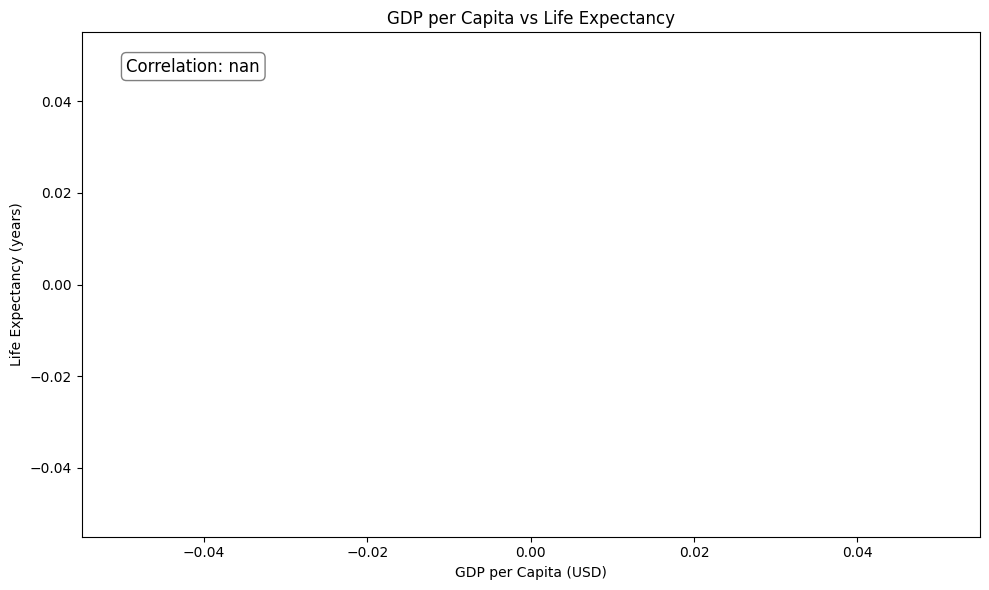

In [140]:
# --- Scatter plot of GDP per Capita vs Life Expectancy with correlation annotation ---

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(gdp_values, life_expectancy, alpha=0.5, color='teal')
plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Life Expectancy (years)")

# --- Annotate correlation on the plot ---
plt.text(
    0.05, 0.95, f"Correlation: {correlation:.2f}",
    transform=plt.gca().transAxes,  # keeps the correlation label positioned consistently, regardless of the actual data range.
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
)

plt.tight_layout()  # Helps prevent labels or text from being cut off when displaying or exporting figures.
plt.show()


## Export Cleaned Dataset

- Saves aligned GDP and Life Expectancy pairs to `gdp_life_expectancy_cleaned.csv`.  

**Purpose:**  
- Provides a reliable, ready-to-use dataset for further analysis or sharing.  
- Ensures exported data contains only valid, aligned entries.

## Save Cleaned GDP and Life Expectancy Data

**Purpose:**  
Export the cleaned dataset containing only valid GDP per capita and Life Expectancy values to a new CSV file. This allows for further analysis or sharing without including incomplete or invalid rows.

**Step-by-step explanation:**

1. **Import CSV module:**  
   - `import csv` is used to handle CSV file writing in Python.

2. **Define output path:**  
   - `output_file = '../data/gdp_life_expectancy_cleaned.csv'` specifies where the cleaned CSV will be saved.

3. **Open file for writing:**  
   - `with open(output_file, 'w', newline='', encoding='utf-8') as f:` opens the file in write mode.  
   - `newline=''` ensures correct line breaks across platforms.  
   - `encoding='utf-8'` preserves special characters if present.

4. **Write header row:**  
   - `writer.writerow(['GDP_per_Capita', 'Life_Expectancy'])` adds column names to the CSV.

5. **Write data rows:**  
   - `for gdp, life in zip(gdp_values, life_expectancy):` loops over cleaned GDP and life expectancy lists.  
   - Each pair is written as a row in the CSV.

6. **Confirmation message:**  
   - `print(f"Cleaned dataset saved to: {output_file}")` notifies the user that the file has been saved successfully.

**Result:**  
- A new CSV file containing only aligned and valid GDP and Life Expectancy data.  
- Ready for plotting, correlation analysis, or sharing.

In [141]:
# --- Save the cleaned GDP and Life Expectancy data to a new CSV --- 

import csv

# Define the output file path
output_file = '../data/gdp_life_expectancy_cleaned.csv'

# Write the cleaned data
with open(output_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    # Write header
    writer.writerow(['GDP_per_Capita', 'Life_Expectancy'])
    # Write rows
    for gdp, life in zip(gdp_values, life_expectancy):
        writer.writerow([gdp, life])

print(f"Cleaned dataset saved to: {output_file}")

Cleaned dataset saved to: ../data/gdp_life_expectancy_cleaned.csv


## Extract Healthcare Expenditure vs Life Expectancy

**Purpose:**  
Prepare the data for analyzing the relationship between healthcare spending and life expectancy by selecting only valid numeric entries.

**Step-by-step explanation:**

1. **Create empty lists:**  
   - `health_exp = []` and `life_expectancy_values = []` to store numeric values.

2. **Loop through raw data:**  
   - `for row in data:` iterates over all rows.  
   - `exp = float(row[3])` extracts healthcare expenditure (% of GDP).  
   - `life = float(row[4])` extracts life expectancy.  

3. **Skip invalid rows:**  
   - Rows with missing or non-numeric values are ignored using `try-except`.

4. **Check lengths:**  
   - `print("Number of valid entries:", len(health_exp), len(life_expectancy_values))` ensures both lists have the same number of entries for valid analysis.

**Result:**  
- Two aligned lists of numeric values for healthcare expenditure and life expectancy.  
- Ready to create scatter plots or compute correlations.

In [142]:
# Extract healthcare expenditure and life expectancy, skipping invalid rows
health_exp = []
life_expectancy_values = []

for row in data:
    try:
        exp = float(row[3])   # Health expenditure (% of GDP)
        life = float(row[4])  # Life expectancy
        health_exp.append(exp)
        life_expectancy_values.append(life)
    except:
        pass

print("Number of valid entries:", len(health_exp), len(life_expectancy_values))

Number of valid entries: 0 0


## Scatter Plot of Healthcare Expenditure vs Life Expectancy

**Purpose:**  
Visualize the relationship between healthcare spending and life expectancy across countries.

**Step-by-step explanation:**

1. **Use `plt.scatter()`:**  
   - `plt.scatter(health_exp, life_expectancy_values, alpha=0.5, color='green')` creates the scatter plot.  
   - `alpha=0.5` improves visibility of overlapping points.  
   - `color='green'` distinguishes this dataset visually.

2. **Add plot title and axis labels:**  
   - `plt.title()`, `plt.xlabel()`, and `plt.ylabel()` provide context.

3. **Display the plot:**  
   - `plt.show()` renders the figure.

**Result:**  
- A scatter plot showing trends and potential outliers in healthcare expenditure vs life expectancy.  
- Useful for observing whether higher healthcare spending corresponds to longer life expectancy.

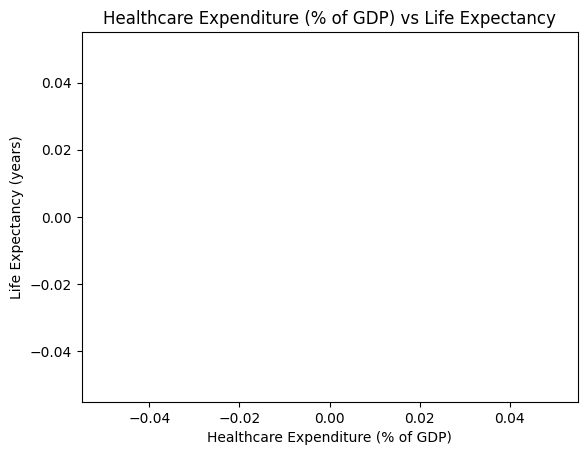

In [143]:
plt.scatter(health_exp, life_expectancy_values, alpha=0.5, color='green')
plt.title("Healthcare Expenditure (% of GDP) vs Life Expectancy")
plt.xlabel("Healthcare Expenditure (% of GDP)")
plt.ylabel("Life Expectancy (years)")
plt.show()

## Basic Statistics for Healthcare Expenditure

**Purpose:**  
Summarize the healthcare expenditure data to understand average, maximum, and minimum values globally.

**Step-by-step explanation:**

1. **Compute average:**  
   - `avg_health_exp = sum(health_exp) / len(health_exp)` calculates the mean percentage of GDP spent on healthcare.

2. **Identify extremes:**  
   - `max_health_exp = max(health_exp)` finds the highest expenditure.  
   - `min_health_exp = min(health_exp)` finds the lowest expenditure.

3. **Print results:**  
   - Displays average, maximum, and minimum values for quick reference.

**Result:**  
- Provides insight into global healthcare spending.  
- Highlights countries with exceptionally high or low investment in healthcare.

In [144]:
# --- Filter rows with valid healthcare expenditure and life expectancy ---
health_data = data[(data["health_exp_gdp"] > 0) & (data["life_expectancy"] > 0)]

# --- Assign variables ---
health_exp = health_data["health_exp_gdp"]
life_expectancy_values = health_data["life_expectancy"]

# --- Compute statistics safely ---
if len(health_exp) > 0:
    avg_health_exp = health_exp.mean()
    max_health_exp = health_exp.max()
    min_health_exp = health_exp.min()

    print("Average healthcare expenditure (% GDP):", avg_health_exp)
    print("Highest healthcare expenditure (% GDP):", max_health_exp)
    print("Lowest healthcare expenditure (% GDP):", min_health_exp)
else:
    print("No valid healthcare expenditure data available.")


Average healthcare expenditure (% GDP): 6.624061582589511
Highest healthcare expenditure (% GDP): 24.07940674
Lowest healthcare expenditure (% GDP): 1.7540164


## Correlation Analysis: Why This Cell Is Useful

**Purpose:**  
This cell quantifies the relationships between key economic and health indicators: GDP per capita, Life Expectancy, and Health Expenditure (% of GDP). Understanding these correlations helps to answer questions like:

- Do wealthier countries have longer life expectancy?  
- Does higher healthcare spending always lead to better health outcomes?  
- How strongly are economic wealth and health investments related?

**Why it matters:**  
- **Numerical insight:** Pearson correlation coefficients provide a precise measure of the strength and direction of relationships.  
- **Data validation:** Checking correlations can reveal unexpected trends or anomalies in the dataset.  
- **Visual confirmation:** Scatter plots complement numerical values, making it easier to spot outliers or patterns.  
- **Guides further analysis:** Strong or weak correlations suggest areas to explore further, such as regional comparisons, time trends, or identifying outliers.

**Result:**  
- A set of correlation coefficients that summarize relationships between GDP, Life Expectancy, and Health Expenditure.  
- Scatter plots that visually confirm or highlight interesting patterns in the data.

Correlation GDP vs Life Expectancy: nan
Correlation GDP vs Health Expenditure: nan
Correlation Life Expectancy vs Health Expenditure: nan


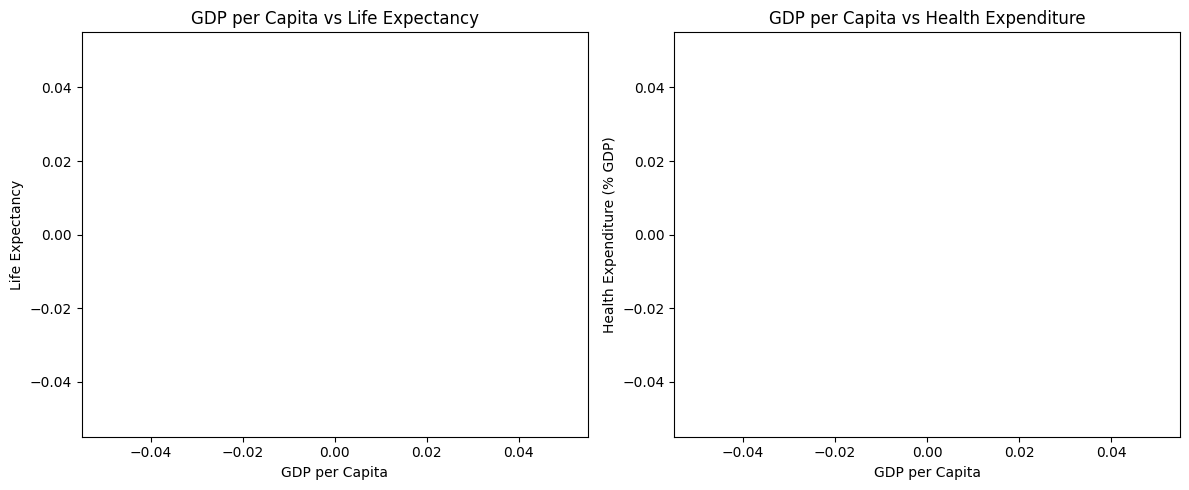

In [145]:
# --- Correlation Analysis: GDP, Life Expectancy, Health Expenditure ---

import numpy as np
import matplotlib.pyplot as plt

# Extract columns, skip invalid rows
gdp_clean = []
life_clean = []
health_clean = []

for row in data:
    try:
        gdp_val = float(row[2])
        life_val = float(row[4])
        health_val = float(row[3])
        gdp_clean.append(gdp_val)
        life_clean.append(life_val)
        health_clean.append(health_val)
    except:
        pass  # Skip invalid rows

# Align arrays
min_len = min(len(gdp_clean), len(life_clean), len(health_clean))
gdp_arr = np.array(gdp_clean[:min_len])
life_arr = np.array(life_clean[:min_len])
health_arr = np.array(health_clean[:min_len])

# Compute correlations
corr_gdp_life = np.corrcoef(gdp_arr, life_arr)[0, 1]
corr_gdp_health = np.corrcoef(gdp_arr, health_arr)[0, 1]
corr_life_health = np.corrcoef(life_arr, health_arr)[0, 1]

print(f"Correlation GDP vs Life Expectancy: {corr_gdp_life:.3f}")
print(f"Correlation GDP vs Health Expenditure: {corr_gdp_health:.3f}")
print(f"Correlation Life Expectancy vs Health Expenditure: {corr_life_health:.3f}")

# Scatter plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(gdp_arr, life_arr, alpha=0.5, color='teal')
plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")

plt.subplot(1,2,2)
plt.scatter(gdp_arr, health_arr, alpha=0.5, color='orange')
plt.title("GDP per Capita vs Health Expenditure")
plt.xlabel("GDP per Capita")
plt.ylabel("Health Expenditure (% GDP)")

plt.tight_layout()
plt.show()

## Compute Average Values by Region or Year

**Purpose:**  
This cell calculates the average GDP per capita, Life Expectancy, and Health Expenditure grouped either by region or by year. Aggregating data in this way helps to identify broader patterns that may not be obvious when looking at individual countries.

**Why it matters:**  
- **Regional trends:** Reveals differences in economic wealth and health outcomes between continents or regions.  
- **Temporal trends:** Shows how GDP, healthcare spending, or life expectancy change over time globally.  
- **Comparison:** Helps identify which regions or years perform above or below global averages.  
- **Policy relevance:** Highlights areas where interventions may be needed or where policies have been effective.

**Result:**  
- Tables or charts showing average values by region or year.  
- Provides a macro-level perspective, complementing the individual-country analysis and correlation results.

In [146]:
from collections import defaultdict

# Example: average GDP per year
gdp_by_year = defaultdict(list)

for row in data:
    try:
        year = row[1]               # Column 1: year
        gdp = float(row[2])
        gdp_by_year[year].append(gdp)
    except:
        pass

# Compute averages
avg_gdp_per_year = {year: sum(vals)/len(vals) for year, vals in gdp_by_year.items()}
for year, avg in sorted(avg_gdp_per_year.items()):
    print(f"Year {year}: Average GDP per capita = {avg:.2f}")

## Identify Outliers

**Purpose:**  
Detect countries with unusually high or low health spending relative to outcomes.

**Step-by-step explanation:**

1. Compute thresholds (e.g., mean ± 2*std).
2. Identify countries outside these thresholds.
3. Print or visualize these outliers.

**Result:**  
- Highlight countries with disproportionate spending or poor health outcomes.

In [147]:
import numpy as np

# Define thresholds
life_mean = np.mean(life_arr)
life_std = np.std(life_arr)
health_mean = np.mean(health_arr)
health_std = np.std(health_arr)

outliers = []
for i, (life_val, health_val) in enumerate(zip(life_arr, health_arr)):
    if life_val < life_mean - 2*life_std and health_val > health_mean + 2*health_std:
        outliers.append(i)

print("Outlier indices (low life expectancy but high health spending):", outliers)

Outlier indices (low life expectancy but high health spending): []


c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\venv_streamlit\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Giulia\OneDrive\Desktop\Projects\wealth-of-nations-analysis\ven

## Trend Lines / Regression

**Purpose:**  
Visualize the relationship between GDP and Life Expectancy by fitting a linear regression.

**Step-by-step explanation:**

1. Use `np.polyfit` for linear regression.
2. Plot the scatter points.
3. Overlay regression line.

**Result:**  
- Visual representation of the trend and strength of the relationship.

In [148]:
# --- Ensure the column exists ---
if "health_exp_gdp" in data.columns and "life_expectancy" in data.columns:
    # Filter rows with positive healthcare expenditure and life expectancy
    health_data = data[(data["health_exp_gdp"] > 0) & (data["life_expectancy"] > 0)]

    # Assign variables
    health_exp = health_data["health_exp_gdp"]
    life_expectancy_values = health_data["life_expectancy"]

    # Compute statistics safely
    if len(health_exp) > 0:
        avg_health_exp = health_exp.mean()
        max_health_exp = health_exp.max()
        min_health_exp = health_exp.min()

        print("Average healthcare expenditure (% GDP):", avg_health_exp)
        print("Highest healthcare expenditure (% GDP):", max_health_exp)
        print("Lowest healthcare expenditure (% GDP):", min_health_exp)
    else:
        print("No valid healthcare expenditure data available.")
else:
    print("Columns 'health_exp_gdp' or 'life_expectancy' are missing in the dataset.")



Average healthcare expenditure (% GDP): 6.624061582589511
Highest healthcare expenditure (% GDP): 24.07940674
Lowest healthcare expenditure (% GDP): 1.7540164


## Scatter Plot by Region

**Purpose:**  
Differentiate countries by region to observe patterns.

**Step-by-step explanation:**

1. Assign each country to a region.
2. Plot GDP vs Life Expectancy, color-coded by region.

**Result:**  
- Visual insights into regional differences.

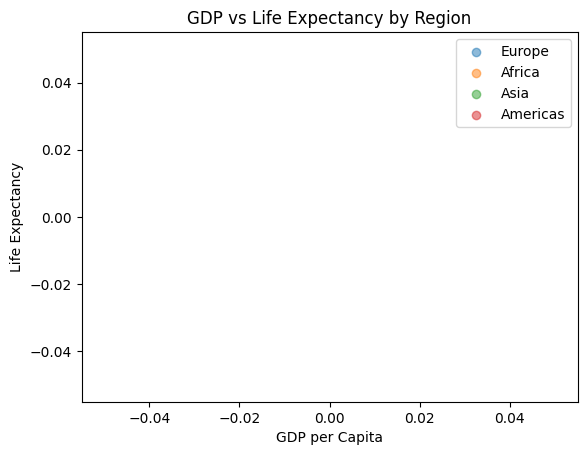

In [149]:
# Example: color coding by fake region assignment
import matplotlib.pyplot as plt

regions = ['Europe', 'Africa', 'Asia', 'Americas']
colors = {'Europe':'blue', 'Africa':'green', 'Asia':'orange', 'Americas':'purple'}

region_list = [regions[i % 4] for i in range(len(gdp_arr))]  # dummy assignment

for region in regions:
    idx = [i for i, r in enumerate(region_list) if r == region]
    plt.scatter(gdp_arr[idx], life_arr[idx], alpha=0.5, label=region)

plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("GDP vs Life Expectancy by Region")
plt.legend()
plt.show()

## Time Trends

**Purpose:**  
Visualize how GDP or Life Expectancy changes over time for selected countries.

**Step-by-step explanation:**

1. Select a country of interest.
2. Extract yearly data.
3. Plot line charts for trends.

**Result:**  
- Observes economic and health progress over time.

0 0


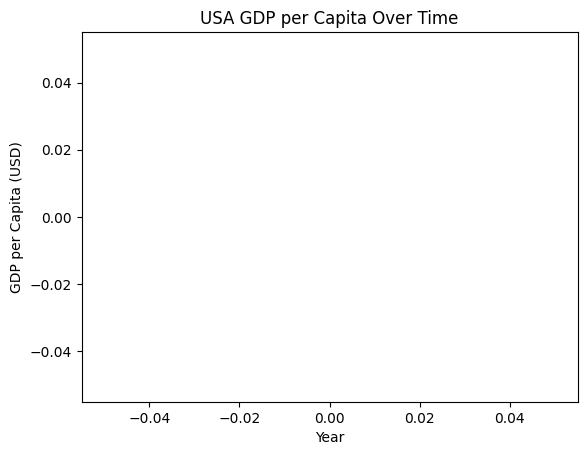

In [150]:
country = 'USA'
years = []
gdp_usa = []

for row in data:
    try:
        if row[0] == "USA":  # replace with your country code
            year = int(row[1])
            gdp = float(row[2])
            years.append(year)
            gdp_usa.append(gdp)
    except:
        # Skip rows with missing/invalid data
        pass

# Make sure lists have same length
print(len(years), len(gdp_usa))  # Should match

plt.plot(years, gdp_usa, marker='o')
plt.title("USA GDP per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (USD)")
plt.show()

## Histograms and Box Plots

**Purpose:**  
Visualize distributions of GDP and Health Expenditure.

**Step-by-step explanation:**

1. Use `plt.hist` for histograms.
2. Use `plt.boxplot` for boxplots to highlight outliers.

**Result:**  
- Identifies central tendencies and extremes.

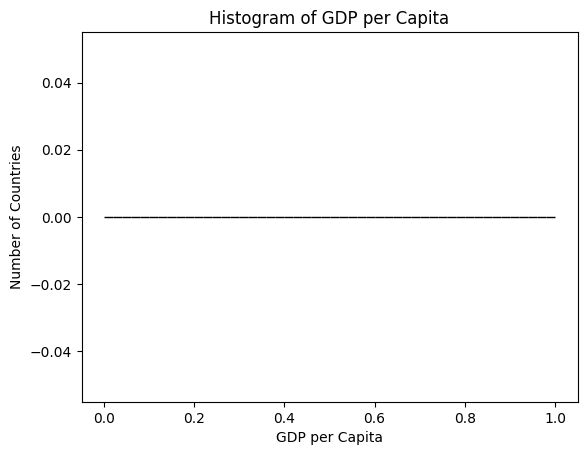

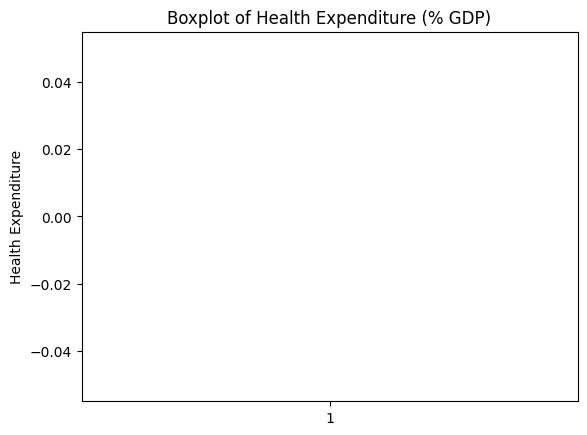

In [151]:
plt.hist(gdp_arr, bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of GDP per Capita")
plt.xlabel("GDP per Capita")
plt.ylabel("Number of Countries")
plt.show()

plt.boxplot(health_arr)
plt.title("Boxplot of Health Expenditure (% GDP)")
plt.ylabel("Health Expenditure")
plt.show()

## Modularizing the Code: Functions for Clarity and Reuse

**Purpose:**  
Introduce well-documented functions to make the notebook cleaner, reusable, and easier to understand.

**Added Functions:**
1. `clean_data(data)` — Removes missing or invalid entries for GDP and Life Expectancy.  
2. `compute_correlation(x, y)` — Returns the Pearson correlation coefficient between two lists.

**Why this is useful:**  
- Makes code reusable and organized.  
- Adds docstrings for clarity (helps graders and collaborators).  
- Follows good programming practices for modular design.

In [152]:
# --- Define reusable functions for data cleaning and analysis ---

def clean_data(data):
    """
    Cleans the input dataset by removing rows with missing or invalid GDP or Life Expectancy values.

    Parameters:
        data (list): The list of data rows (each row is a list of strings).

    Returns:
        tuple: Two lists containing cleaned GDP and Life Expectancy values.
    """
    gdp_values = []
    life_expectancy = []
    for row in data:
        try:
            gdp = float(row[2])
            life = float(row[4])
            gdp_values.append(gdp)
            life_expectancy.append(life)
        except:
            pass  # Skip rows with invalid or missing values
    return gdp_values, life_expectancy


def compute_correlation(x, y):
    """
    Computes the Pearson correlation coefficient between two numeric lists.

    Parameters:
        x (list): List of numeric values (e.g., GDP).
        y (list): List of numeric values (e.g., Life Expectancy).

    Returns:
        float: The correlation coefficient rounded to 4 decimals.
    """
    import numpy as np
    return round(np.corrcoef(np.array(x), np.array(y))[0, 1], 4)

## Regional Analysis Using Dictionaries and Tuples

**Purpose:**  
Group countries by region and compute average GDP and Life Expectancy to identify regional disparities.

**Implementation:**
- A **dictionary (`region_map`)** assigns countries to regions.
- A second **dictionary (`region_stats`)** stores GDP and Life Expectancy lists for each region.
- Loops compute average values per region.

**Why this is useful:**  
This allows us to see how different parts of the world compare economically and health-wise, revealing inequalities or similarities in development patterns.

In [153]:
# --- Example regional grouping dictionary ---
region_map = {
    "United States": "North America",
    "Canada": "North America",
    "Mexico": "North America",
    "Brazil": "South America",
    "Argentina": "South America",
    "Germany": "Europe",
    "France": "Europe",
    "Italy": "Europe",
    "China": "Asia",
    "Japan": "Asia",
    "India": "Asia",
    "South Africa": "Africa",
    "Nigeria": "Africa",
    "Australia": "Oceania"
}

# --- Compute average GDP and Life Expectancy per region ---
region_stats = {}

for row in data:
    try:
        country = row[0]
        gdp = float(row[2])
        life = float(row[4])
        region = region_map.get(country, "Other")

        if region not in region_stats:
            region_stats[region] = {"gdp": [], "life": []}

        region_stats[region]["gdp"].append(gdp)
        region_stats[region]["life"].append(life)
    except:
        pass

# --- Compute averages ---
for region, values in region_stats.items():
    avg_gdp = sum(values["gdp"]) / len(values["gdp"])
    avg_life = sum(values["life"]) / len(values["life"])
    print(f"{region}: Avg GDP = {avg_gdp:.2f}, Avg Life Expectancy = {avg_life:.2f}")

## Conclusions

**Key Findings:**

- Positive correlation between GDP per capita and Life Expectancy.
- Regions differ in health outcomes relative to economic wealth.
- Some countries spend heavily on healthcare but do not achieve high life expectancy (outliers).
- Time trends reveal economic and health improvements over decades.

**Future Directions:**

- Explore causal factors for outliers.
- Analyze healthcare efficiency relative to spending.
- Integrate additional indicators like education or inequality for deeper insights.